# Non-Uniform Azimuthal Poisson Solver:
# Jittered Angular Grid vs. Uniform FFT with Interpolation

$$
u(r,\theta)
=
(R^2-r^2)
\left(\frac{r}{R}\right)^m
\cos\left(m(\theta-\theta_0)\right)
$$

This manufactured Poisson problem is smooth on the full disk, including at
the origin, and satisfies homogeneous Dirichlet boundary conditions:

$$
u(R,\theta)=0.
$$

The angular grid is a jittered mesh: each angle is a uniform cell-center
position perturbed by up to a fixed fraction of one cell width.

All methods begin with the same jittered angular measurements. Adapted NUFFT
(using the Toeplitz/Block-CG solver) and Adapted NUDFT consume those
measurements directly. The Uniform FFT baseline first applies periodic cubic
spline interpolation to place the same measurements on a uniform angular grid
before solving.

In [20]:
import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path (auto-detect from cwd or Tests/paper layout)
_cwd = os.getcwd()
if os.path.isdir(os.path.join(_cwd, "Poisson_Solver")):
    repo_root = _cwd
elif os.path.isdir(os.path.join(_cwd, "..", "..", "Poisson_Solver")):
    repo_root = os.path.abspath(os.path.join(_cwd, "..", ".."))
else:
    repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import Tests.paper.slight_nonuniform_helpers as slight_nonuniform_helpers
importlib.reload(slight_nonuniform_helpers)

from Tests.paper.slight_nonuniform_helpers import (
    get_single_multipole_problem,
    run_all_algorithms_NxM_study,
    plot_solution_and_grids,
    plot_accuracy_faceted_by_method,
    plot_accuracy_from_df,
    plot_adapted_vs_highres_uniform,
    render_combined_error_table,
    render_combined_runtime_table,
    plot_extreme_runtime_2x2,
)

## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [21]:
# ---------------------------------------------------------
# Disk and smooth single-multipole manufactured problem
# ---------------------------------------------------------
R = 1.0
MODE = 16
THETA_0 = np.pi


# ---------------------------------------------------------
# Jittered angular mesh
#
# Each angle is a uniform cell-center perturbed within its sector:
#   theta_j = 2*pi/N * (j + 1/2) + delta_j,
#   |delta_j| <= jitter_fraction * (2*pi/N).
# ---------------------------------------------------------
JITTER_FRACTION = 0.45
GRID_SEED = 42


# ---------------------------------------------------------
# Solver settings
# ---------------------------------------------------------
QUAD_RULE = 2                # 1: Trapezoidal, 2: Simpson
BC_CHOICE = 1                # 1: Dirichlet, 2: Neumann


# ---------------------------------------------------------
# Resolution study
#
# MODE=16 needs enough angular samples. N=64 is the first
# meaningful resolution in this study.
# ---------------------------------------------------------
N_VALUES = [64, 128, 256, 512, 1024]
M_VALUES = [64, 128, 256, 512, 1024]


# ---------------------------------------------------------
# Fixed settings for plots
# ---------------------------------------------------------
N_LOW_ADAPT = 64
N_HIGH_UNIFORM = 1024
M_FIXED_PLOTS = 128

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

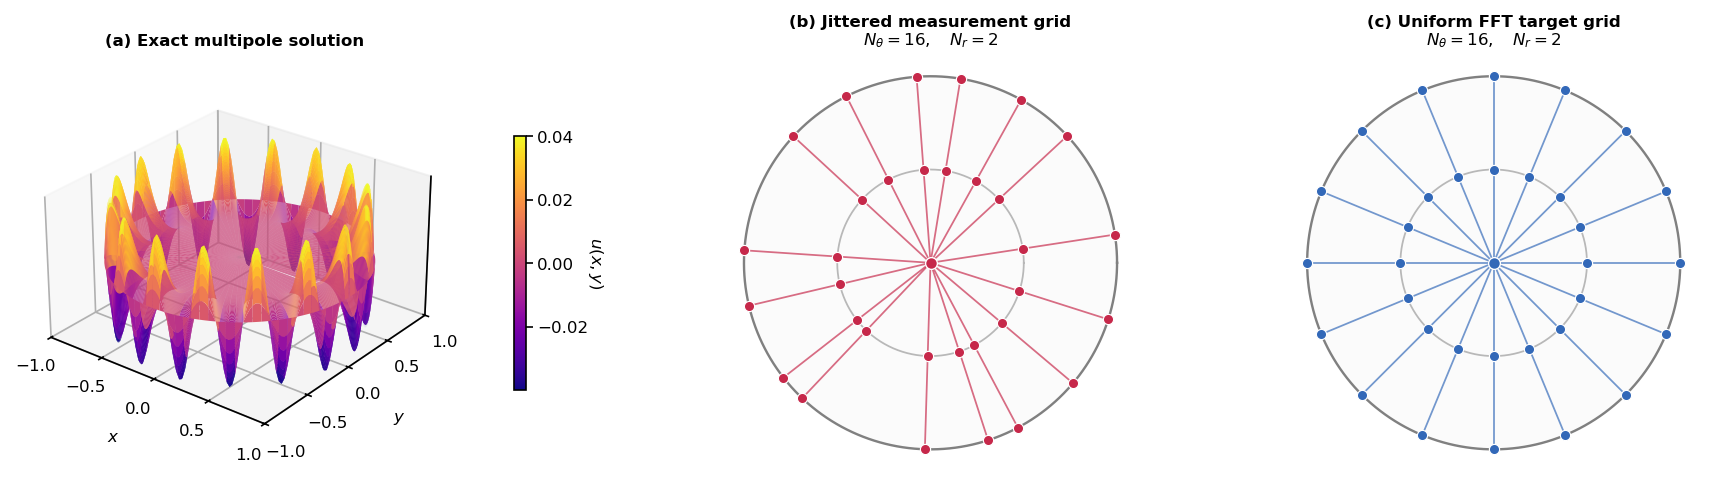

In [22]:
# Construct smooth single-multipole manufactured problem.
problem = get_single_multipole_problem(
    R=R,
    mode=MODE,
    theta_0=THETA_0,
)

# Visualize exact solution, jittered measurement grid,
# and Uniform FFT target grid.
plot_solution_and_grids(
    problem=problem,
    N_adapt=16,
    N_unif=16,
    M=2,
    jitter_fraction=JITTER_FRACTION,
    grid_seed=GRID_SEED,
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [23]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    jitter_fraction=JITTER_FRACTION,
    grid_seed=GRID_SEED,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE,
)

Computing N x M jittered-grid study: 100%|██████████| 75/75 [01:39<00:00,  1.33s/it]


## 4. $L_2$ Error 
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [24]:
# Relative L2 Error Tables for each algorithm
combined_error = render_combined_error_table(df_results, value_col="L2_rel")

## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

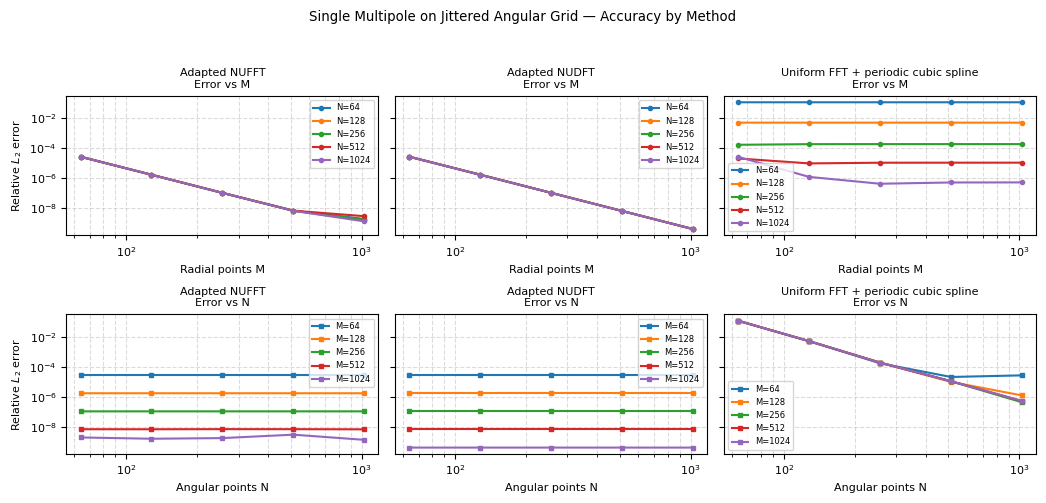

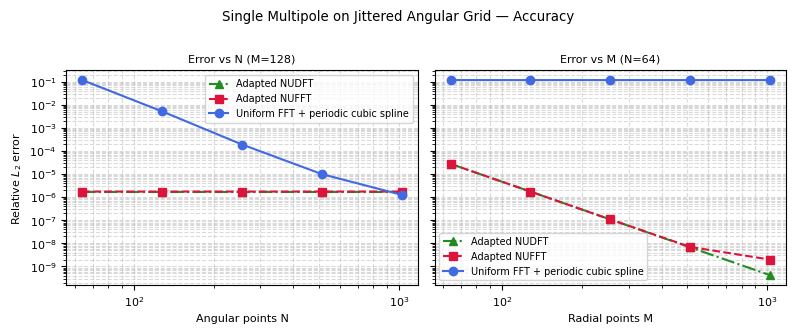

In [25]:
plot_accuracy_faceted_by_method(df_results, N_values=N_VALUES, M_values=M_VALUES)

plot_accuracy_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).


1 x 3 Disk Error Comparison with NUDFT Table Result
                                                   Case    N   M Relative L2 Relative Linf Runtime (s)
                   Adapted NUFFT — direct jittered data   64 128   1.748e-06     1.659e-06      0.0758
                   Adapted NUDFT — direct jittered data   64 128   1.748e-06     1.662e-06      0.0162
  Uniform FFT + interpolation — same measurement budget   64 128   1.172e-01     2.306e-01      0.0063
Uniform FFT + interpolation — higher measurement budget 1024 128   1.256e-06     1.378e-06      0.0679


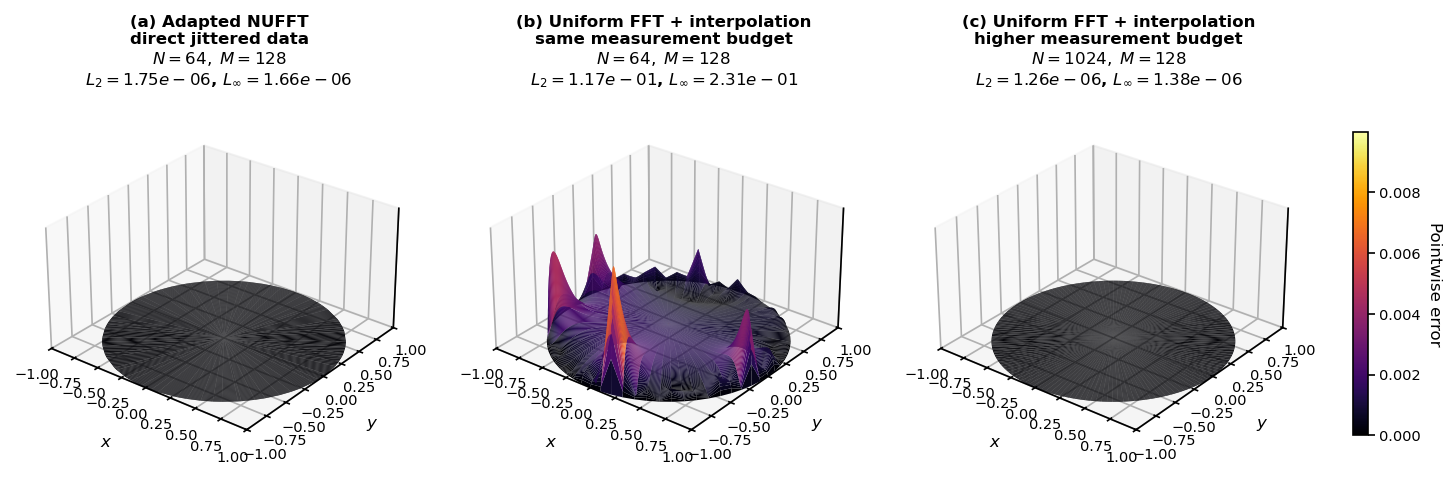

,Case,N,M,Relative L2,Relative Linf,Runtime (s)
0,Adapted NUFFT — direct jittered data,64,128,0.000002,0.000002,0.075806
1,Adapted NUDFT — direct jittered data,64,128,0.000002,0.000002,0.016229
2,Uniform FFT + interpolation — same measurement...,64,128,0.117153,0.230628,0.006331
3,Uniform FFT + interpolation — higher measureme...,1024,128,0.000001,0.000001,0.067862


In [26]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    jitter_fraction=JITTER_FRACTION,
    grid_seed=GRID_SEED,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE,
)

Runtime Tables ($N$ vs. $M$)


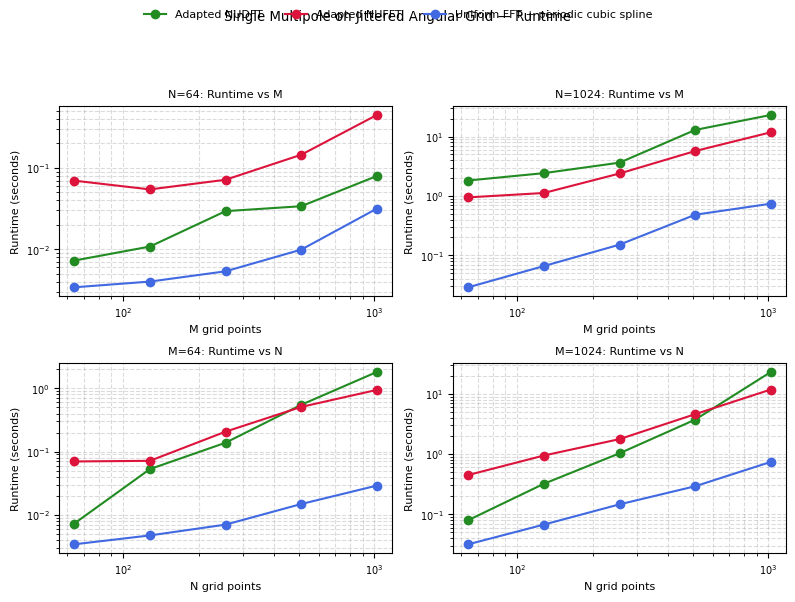

In [27]:
# Runtime (seconds) Tables for each algorithm
combined_runtime = render_combined_runtime_table(df_results)

plot_extreme_runtime_2x2(df_results)